In [2]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [38]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/B_varreduction/pca_variables.csv")
weathercluster_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/weather_fit.csv")
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/station_GEV_7.csv")

# --- Merge labels into stats ---
# Ensure station is comparable dtype
stats_df["station"] = stats_df["station"].astype(int)
GEV_clusters["station"] = GEV_clusters["station"].astype(int)

label_df = GEV_clusters[["station", "cluster", "lat", "lon"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on="station", how="inner")

print("Stations for modeling:", len(model_df))
print(model_df["cluster"].value_counts(dropna=False))

drop_cols = {"station", "cluster"}

# Substrings that indicate leakage / forbidden variables
forbidden_substrings = ( "sea_level", "residual", "tide", "lat", "lon", "count", "missing_frac")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols

# Build feature matrix
X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

y = model_df['cluster']

Stations for modeling: 51012
cluster
3    19926
1    15840
4    11046
6     2082
2     1736
5      357
0       25
Name: count, dtype: int64


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_76158/2638123328.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", k) if k <= 20 else cm.get_cmap("gist_ncar", k)


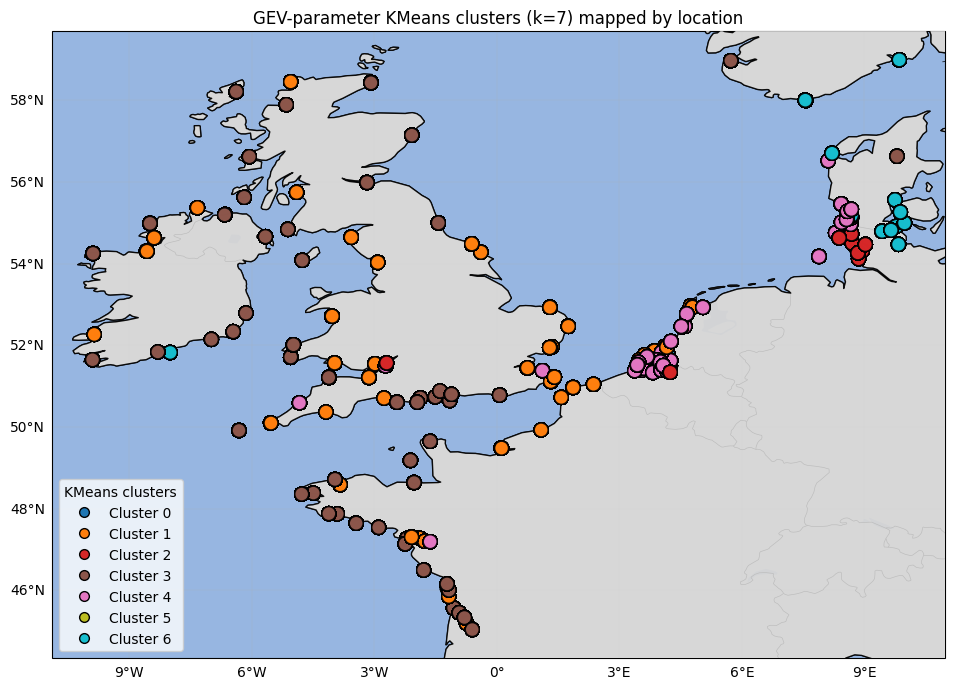

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# dfc must contain: lon, lat, cluster
# best_k is the number of clusters
assert {"lon", "lat", "cluster"}.issubset(model_df.columns)

# Ensure numeric lon/lat and drop missing
plotdf = model_df[["lon", "lat", "cluster"]].copy()
plotdf["lon"] = pd.to_numeric(plotdf["lon"], errors="coerce")
plotdf["lat"] = pd.to_numeric(plotdf["lat"], errors="coerce")
plotdf["cluster"] = pd.to_numeric(plotdf["cluster"], errors="coerce")
plotdf = plotdf.replace([np.inf, -np.inf], np.nan).dropna()

# If best_k not in scope, infer from data
k = int(plotdf["cluster"].nunique())

# --- Map setup ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)

# Set extent with padding (optional but usually helpful)
lon_min, lon_max = plotdf["lon"].min(), plotdf["lon"].max()
lat_min, lat_max = plotdf["lat"].min(), plotdf["lat"].max()

pad_lon = max(0.5, 0.05 * (lon_max - lon_min))
pad_lat = max(0.5, 0.05 * (lat_max - lat_min))
ax.set_extent(
    [lon_min - pad_lon, lon_max + pad_lon, lat_min - pad_lat, lat_max + pad_lat],
    crs=ccrs.PlateCarree()
)

# Base features
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)

# Categorical colors for clusters
cmap = cm.get_cmap("tab10", k) if k <= 20 else cm.get_cmap("gist_ncar", k)
norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, k + 0.5, 1), ncolors=k)



# Land on top (so land masks points if you prefer). Adjust alpha as needed.
land = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", facecolor="lightgray", edgecolor="black"
)
ax.add_feature(land, alpha=0.9, zorder=5)

# Optional: gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Legend (categorical)
# Build custom legend handles
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="",
               markersize=7, markerfacecolor=cmap(i), markeredgecolor="k",
               label=f"Cluster {i}")
    for i in range(k)
]

# Scatter points (clusters)
sc = ax.scatter(
    plotdf["lon"].values,
    plotdf["lat"].values,
    c=plotdf["cluster"].values,
    cmap=cmap,
    norm=norm,
    s=100,
    zorder=40,
    alpha=0.9,
    transform=ccrs.PlateCarree(),
    edgecolors='black')
ax.set_title(f"GEV-parameter KMeans clusters (k={k}) mapped by location")
ax.legend(handles=handles, title="KMeans clusters", loc="lower left", frameon=True)
plt.tight_layout()
plt.show()


In [13]:
# Ensure cluster exists
assert "cluster" in model_df.columns, "cluster column not found in model_df"

# Compute cluster-wise means (numeric columns only)
cluster_means = (
    model_df
    .groupby("cluster")
    .mean(numeric_only=True)
)

print(cluster_means)


           Unnamed: 0  wind_wave_alignment        tp         mwd       mwp  \
cluster                                                                      
0         9145.000000            -0.062934  0.000288  197.018834  5.628266   
1        23687.702715            -0.013859  0.000421  241.939531  5.729145   
2        30125.273618            -0.033352  0.000216  277.545336  6.282519   
3        28996.045920            -0.010720  0.000614  216.428908  6.495318   
4        20337.143762             0.001064  0.000306  273.136927  6.186689   
5         6371.000000            -0.041266  0.000109  236.223775  5.807236   
6        32974.787224            -0.015020  0.000261  230.010512  5.972902   

          v10_abs    wind_dir     tau_v   u10_abs       swh             sp  \
cluster                                                                      
0        7.171720   50.295937  0.615421  6.280152  2.291092  100298.861720   
1        6.143922  113.956736  0.158880  7.253170  1.894339   9

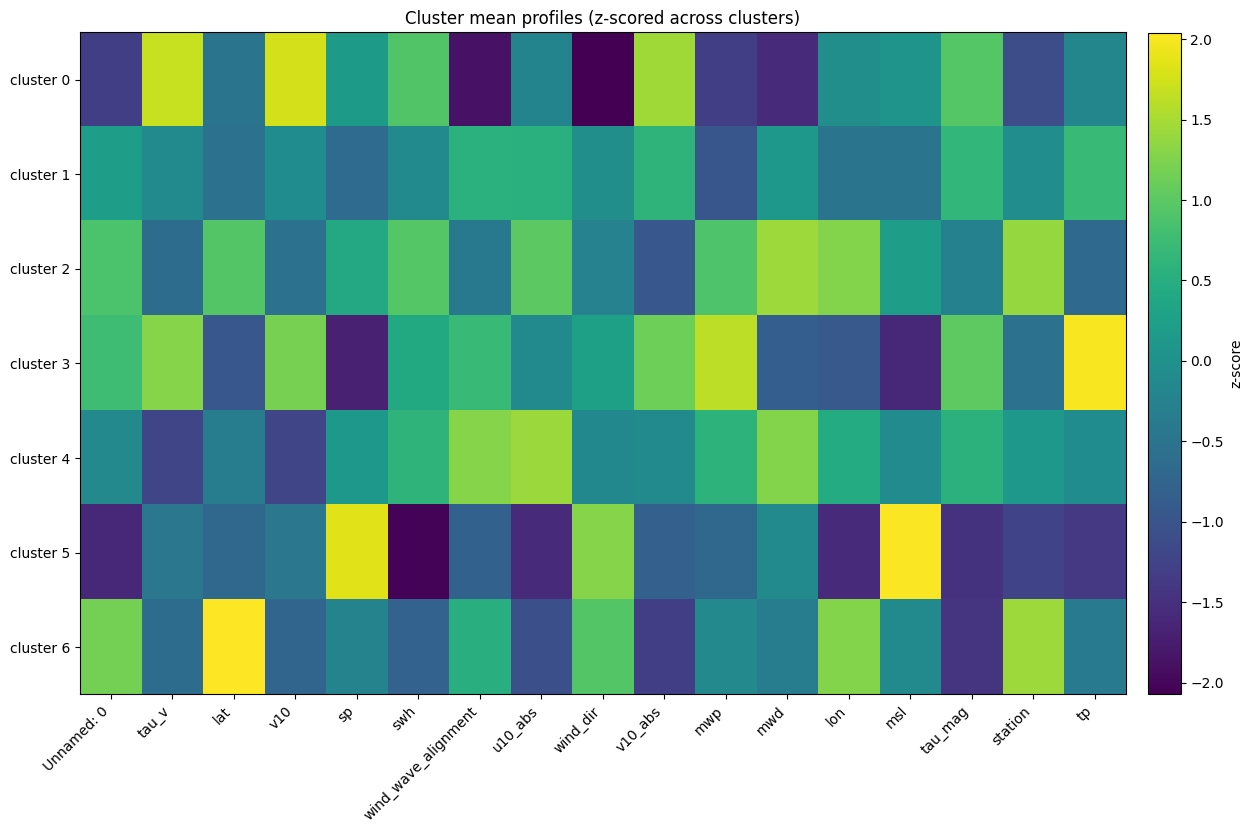

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- compute cluster means if you haven't already ---
cluster_means = model_df.groupby("cluster").mean(numeric_only=True)

# Optional: drop columns you don't want to visualize
# drop_cols = ["some_id_col"]
# cluster_means = cluster_means.drop(columns=[c for c in drop_cols if c in cluster_means.columns])

# --- z-score columns across clusters for visual comparability ---
Z = (cluster_means - cluster_means.mean(axis=0)) / cluster_means.std(axis=0, ddof=0)
Z = Z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# --- sort variables by overall spread across clusters (most informative left) ---
var_order = Z.std(axis=0).sort_values(ascending=False).index
Z = Z[var_order]

# --- plot heatmap ---
fig, ax = plt.subplots(figsize=(min(18, 0.6 * Z.shape[1] + 4), 0.8 * Z.shape[0] + 3))

im = ax.imshow(Z.values, aspect="auto")

ax.set_yticks(range(Z.shape[0]))
ax.set_yticklabels([f"cluster {c}" for c in Z.index])

ax.set_xticks(range(Z.shape[1]))
ax.set_xticklabels(Z.columns, rotation=45, ha="right")

ax.set_title("Cluster mean profiles (z-scored across clusters)")
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("z-score")

# Annotate values (op


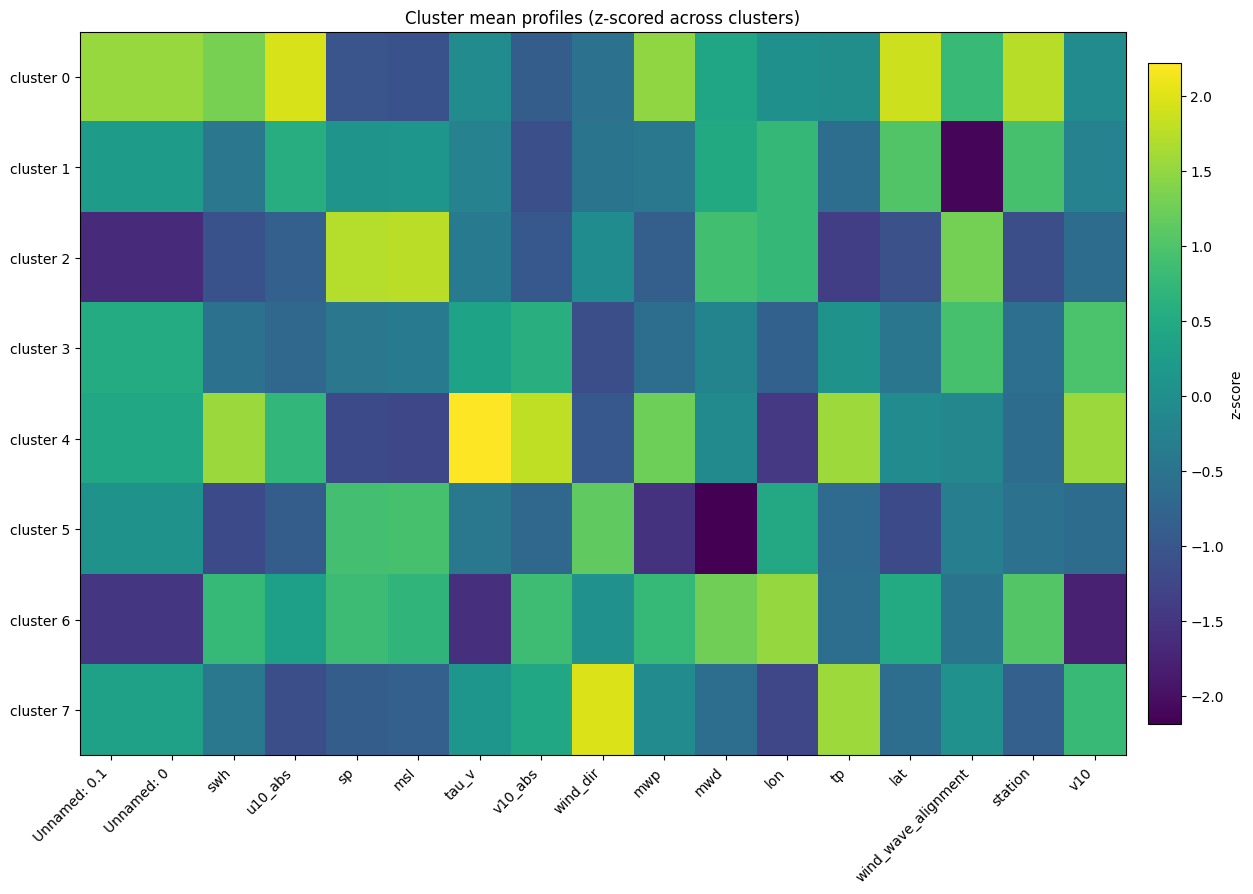

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- compute cluster means if you haven't already ---
cluster_means = weathercluster_df.groupby("cluster").mean(numeric_only=True)

# Optional: drop columns you don't want to visualize
# drop_cols = ["some_id_col"]
# cluster_means = cluster_means.drop(columns=[c for c in drop_cols if c in cluster_means.columns])

# --- z-score columns across clusters for visual comparability ---
Z = (cluster_means - cluster_means.mean(axis=0)) / cluster_means.std(axis=0, ddof=0)
Z = Z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# --- sort variables by overall spread across clusters (most informative left) ---
var_order = Z.std(axis=0).sort_values(ascending=False).index
Z = Z[var_order]

# --- plot heatmap ---
fig, ax = plt.subplots(figsize=(min(18, 0.6 * Z.shape[1] + 4), 0.8 * Z.shape[0] + 3))

im = ax.imshow(Z.values, aspect="auto")

ax.set_yticks(range(Z.shape[0]))
ax.set_yticklabels([f"cluster {c}" for c in Z.index])

ax.set_xticks(range(Z.shape[1]))
ax.set_xticklabels(Z.columns, rotation=45, ha="right")

ax.set_title("Cluster mean profiles (z-scored across clusters)")
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("z-score")

# Annotate values (op

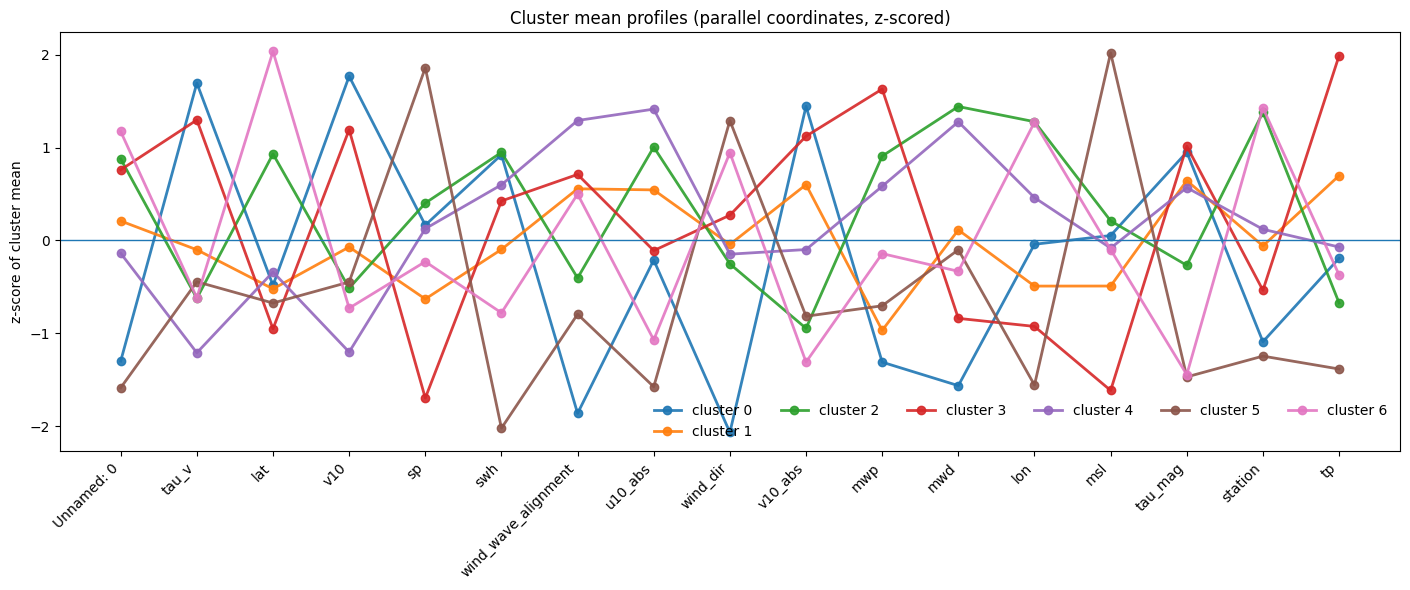

In [21]:
import numpy as np
import matplotlib.pyplot as plt

cluster_means = model_df.groupby("cluster").mean(numeric_only=True)

# z-score for comparability
Z = (cluster_means - cluster_means.mean(axis=0)) / cluster_means.std(axis=0, ddof=0)
Z = Z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# order variables by spread (optional)
var_order = Z.std(axis=0).sort_values(ascending=False).index
Z = Z[var_order]

x = np.arange(Z.shape[1])

plt.figure(figsize=(min(18, 0.6 * Z.shape[1] + 4), 6))
for c in Z.index:
    plt.plot(x, Z.loc[c].values, marker="o", linewidth=2, alpha=0.9, label=f"cluster {c}")

plt.axhline(0, linewidth=1)
plt.xticks(x, Z.columns, rotation=45, ha="right")
plt.ylabel("z-score of cluster mean")
plt.title("Cluster mean profiles (parallel coordinates, z-scored)")
plt.legend(ncol=min(6, len(Z.index)), frameon=False)
plt.tight_layout()
plt.show()


# KDE on cluster 2 waves

In [40]:
import numpy as np
import pandas as pd

# Ensure required columns exist
required_cols = ["cluster", "u10_abs", "v10_abs"]
missing = [c for c in required_cols if c not in model_df.columns]
assert not missing, f"Missing columns: {missing}"

# Subset cluster 0
d2 = (
    model_df
    .loc[model_df["cluster"] == 2, ["u10_abs", "v10_abs"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

X = d2["u10_abs"].values
Y = d2["v10_abs"].values

print(f"Cluster 2 samples: {len(X)}")


Cluster 2 samples: 1736


In [41]:
from scipy.stats import gaussian_kde

# Stack for KDE
values = np.vstack([X, Y])

kde = gaussian_kde(values)

# Evaluation grid
xmin, xmax = X.min(), X.max()
ymin, ymax = Y.min(), Y.max()

xx, yy = np.mgrid[
    xmin:xmax:200j,
    ymin:ymax:200j,
]

grid_coords = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(grid_coords).reshape(xx.shape)


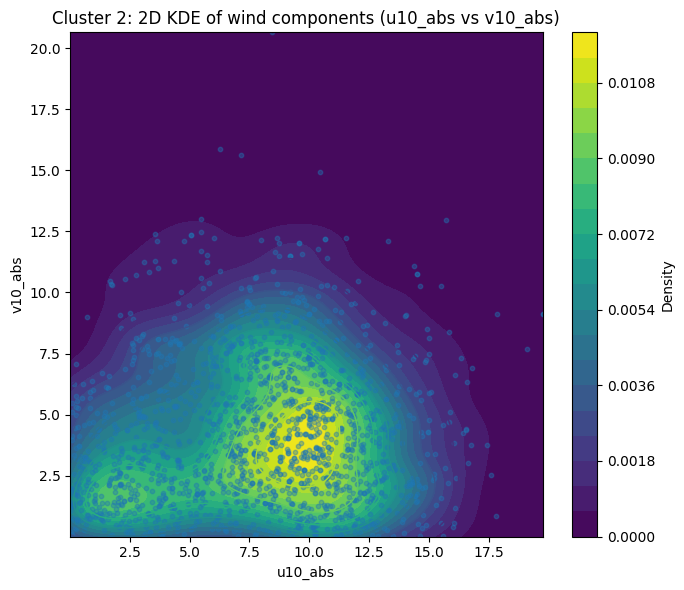

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

# Filled density
cf = plt.contourf(
    xx, yy, zz,
    levels=20,
)

# Contours
plt.contour(
    xx, yy, zz,
    levels=10,
    linewidths=1,
)

# Scatter overlay (light, for context)
plt.scatter(
    X, Y,
    s=10,
    alpha=0.4,
)

plt.xlabel("u10_abs")
plt.ylabel("v10_abs")
plt.title("Cluster 2: 2D KDE of wind components (u10_abs vs v10_abs)")

cbar = plt.colorbar(cf)
cbar.set_label("Density")

plt.tight_layout()
plt.show()


# u10_abs GEV

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
def extract_u(df, cluster_id, col="u10_abs"):
    u = (
        df.loc[df["cluster"] == cluster_id, col]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .to_numpy(dtype=float)
    )
    return u
def kde_overlap(u1, u2, ngrid=2000):
    """
    Returns overlap coefficient and L1 distance
    """
    kde1 = gaussian_kde(u1)
    kde2 = gaussian_kde(u2)

    xmin = min(u1.min(), u2.min())
    xmax = max(u1.max(), u2.max())
    x = np.linspace(xmin, xmax, ngrid)

    f1 = kde1(x)
    f2 = kde2(x)

    overlap = np.trapz(np.minimum(f1, f2), x)
    l1 = np.trapz(np.abs(f1 - f2), x)

    return overlap, l1, x, f1, f2


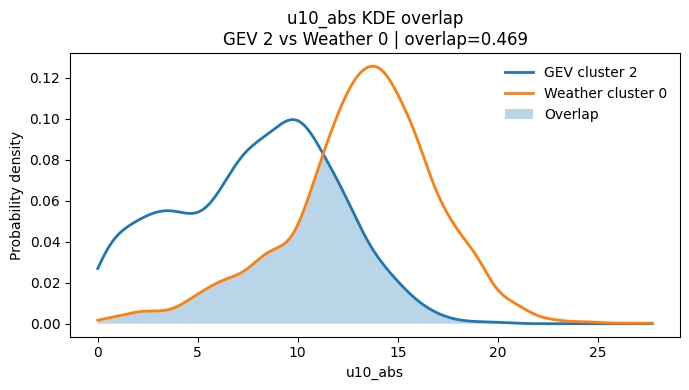

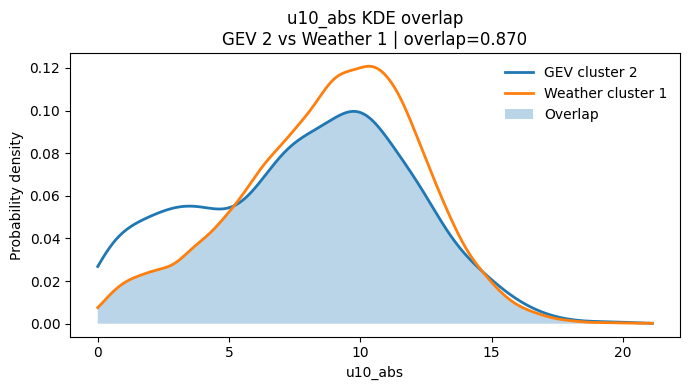

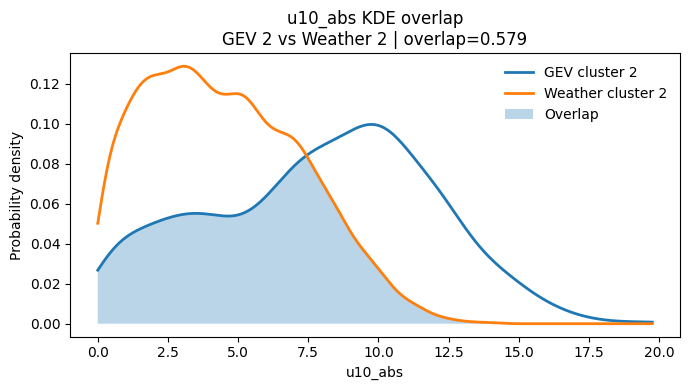

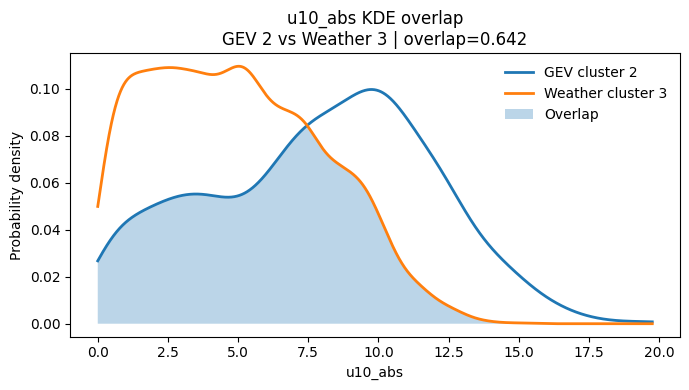

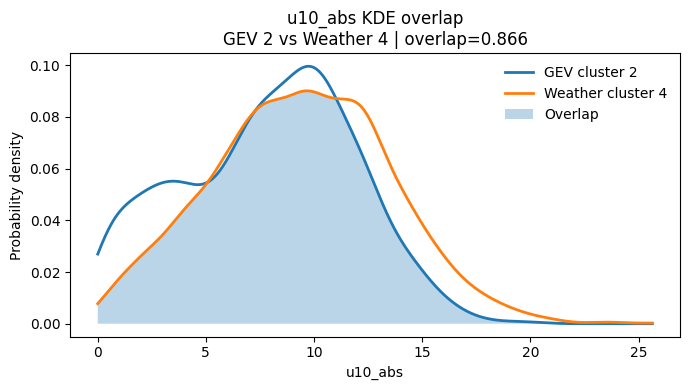

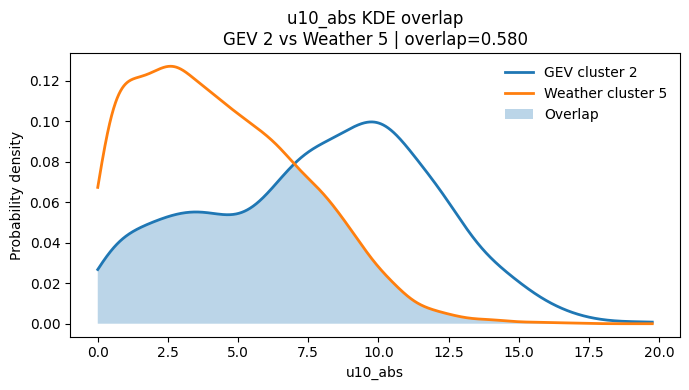

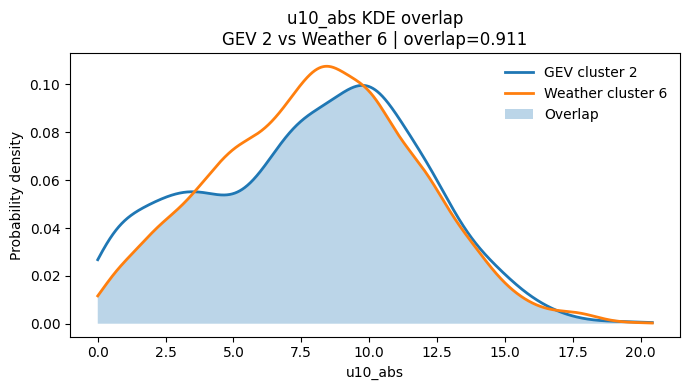

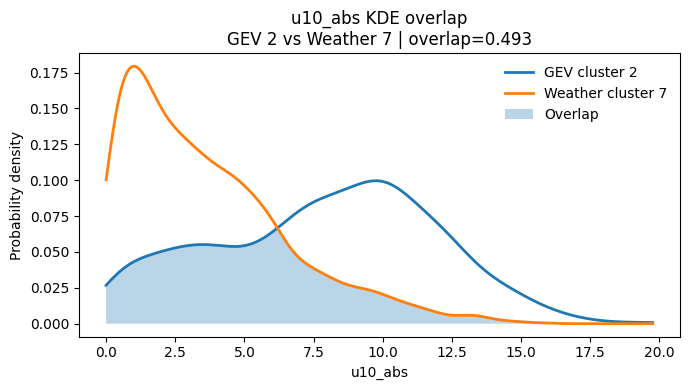

In [50]:
GEV_CLUSTER = 2
WEATHER_CLUSTERS = range(8)  # 0–7

u_gev = extract_u(model_df, GEV_CLUSTER)

if len(u_gev) < 5:
    raise ValueError("Not enough samples in GEV cluster 2 for KDE.")

rows = []

for wc in WEATHER_CLUSTERS:
    u_w = extract_u(weathercluster_df, wc)

    if len(u_w) < 5:
        print(f"Skipping weather cluster {wc}: too few samples")
        continue

    overlap, l1, x, f_gev, f_w = kde_overlap(u_gev, u_w)

    rows.append({
        "gev_cluster": GEV_CLUSTER,
        "weather_cluster": wc,
        "n_gev": len(u_gev),
        "n_weather": len(u_w),
        "overlap": overlap,
        "l1_distance": l1,
    })

    # -------------------------
    # Plot KDE overlap
    # -------------------------
    plt.figure(figsize=(7, 4))
    plt.plot(x, f_gev, linewidth=2, label=f"GEV cluster {GEV_CLUSTER}")
    plt.plot(x, f_w, linewidth=2, label=f"Weather cluster {wc}")
    plt.fill_between(x, 0, np.minimum(f_gev, f_w), alpha=0.3, label="Overlap")

    plt.xlabel("u10_abs")
    plt.ylabel("Probability density")
    plt.title(
        f"u10_abs KDE overlap\n"
        f"GEV {GEV_CLUSTER} vs Weather {wc} | overlap={overlap:.3f}"
    )
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


In [51]:
overlap_df = pd.DataFrame(rows)

overlap_df = overlap_df.sort_values("overlap", ascending=False).reset_index(drop=True)

print(overlap_df)


   gev_cluster  weather_cluster  n_gev  n_weather   overlap  l1_distance
0            2                6   1736       5125  0.910841     0.151832
1            2                1   1736      10962  0.870028     0.236411
2            2                4   1736       4471  0.866500     0.241958
3            2                3   1736       8763  0.642138     0.675135
4            2                5   1736       2914  0.579914     0.786339
5            2                2   1736       8975  0.579373     0.802347
6            2                7   1736       4668  0.493245     0.948564
7            2                0   1736       5134  0.468882     1.040733


In [59]:
model_df.cluster.unique()

array([3, 1, 4, 5, 6, 0, 2])

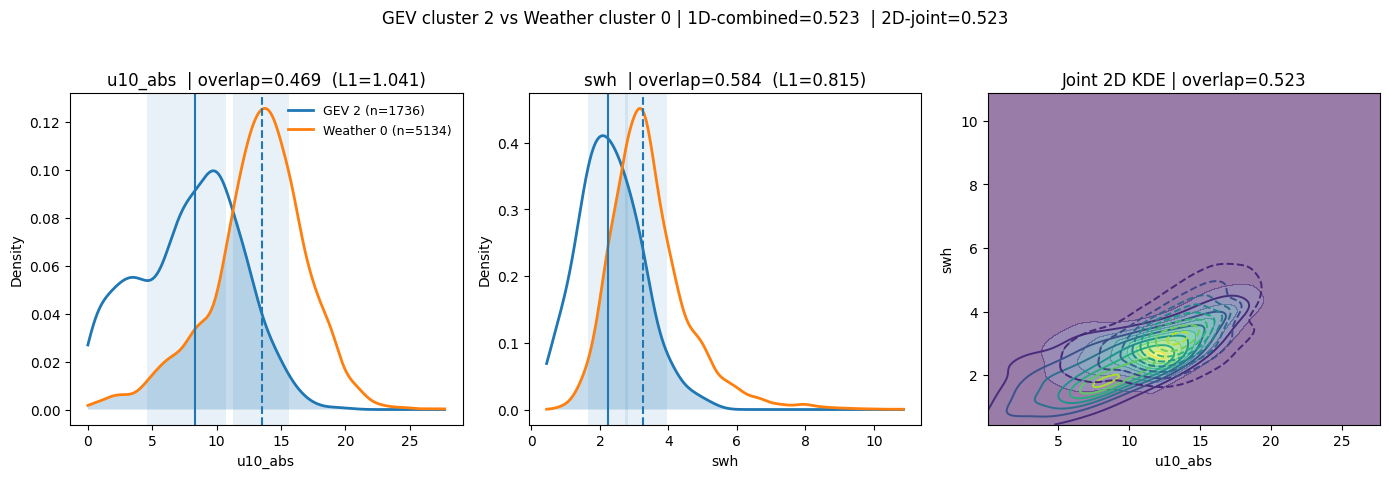

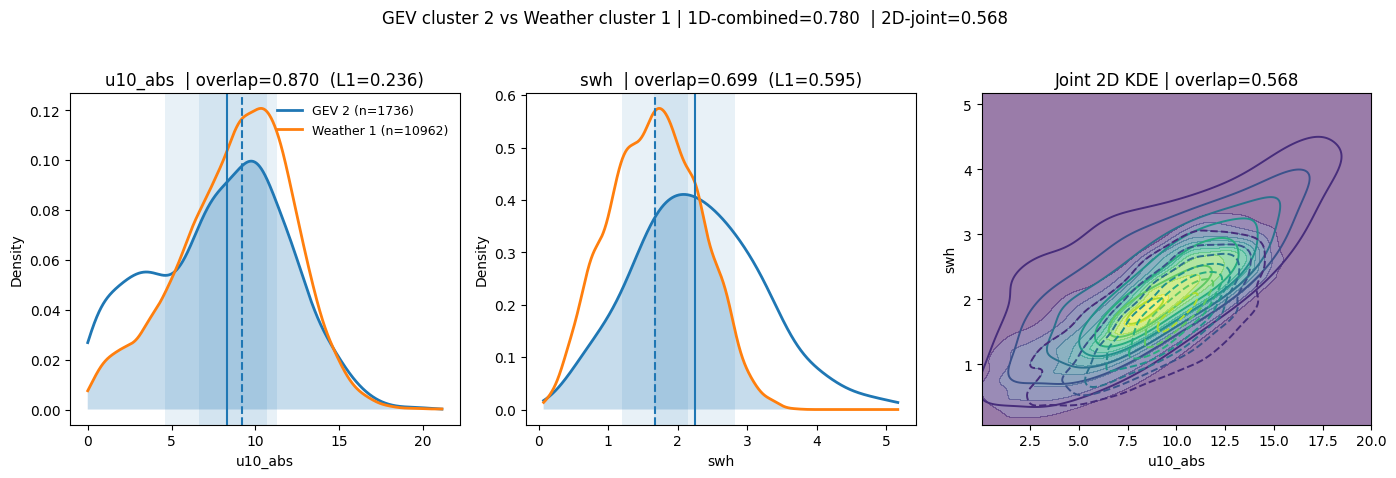

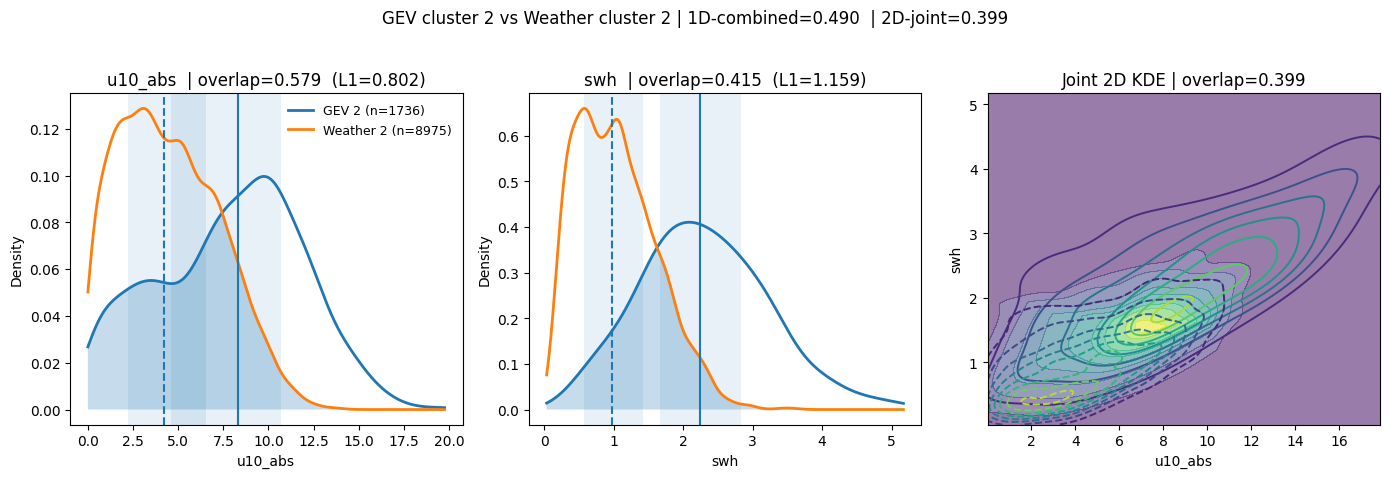

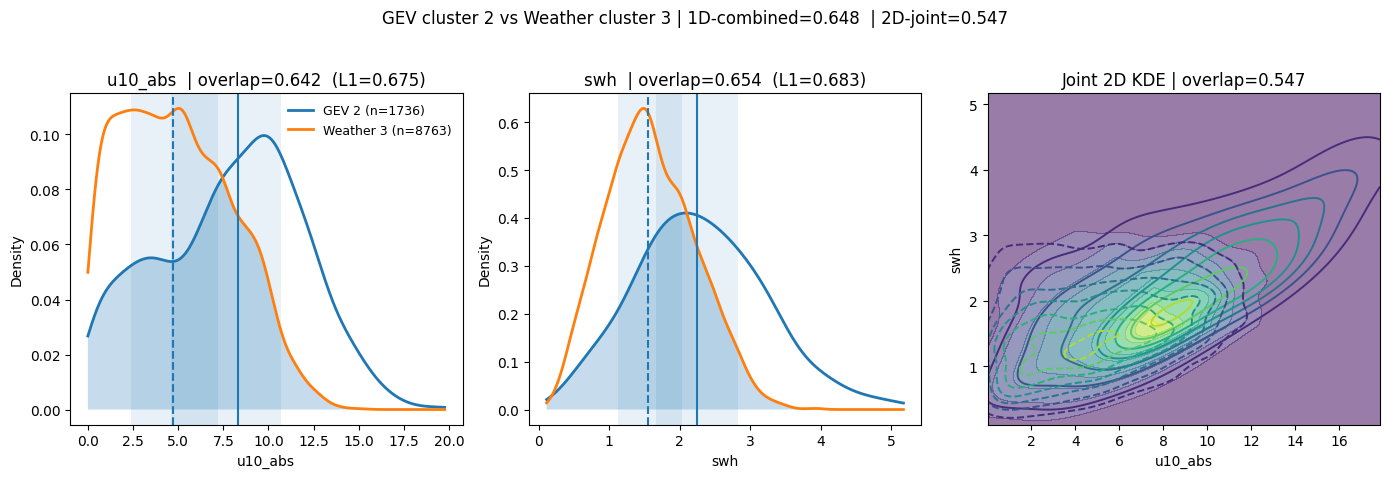

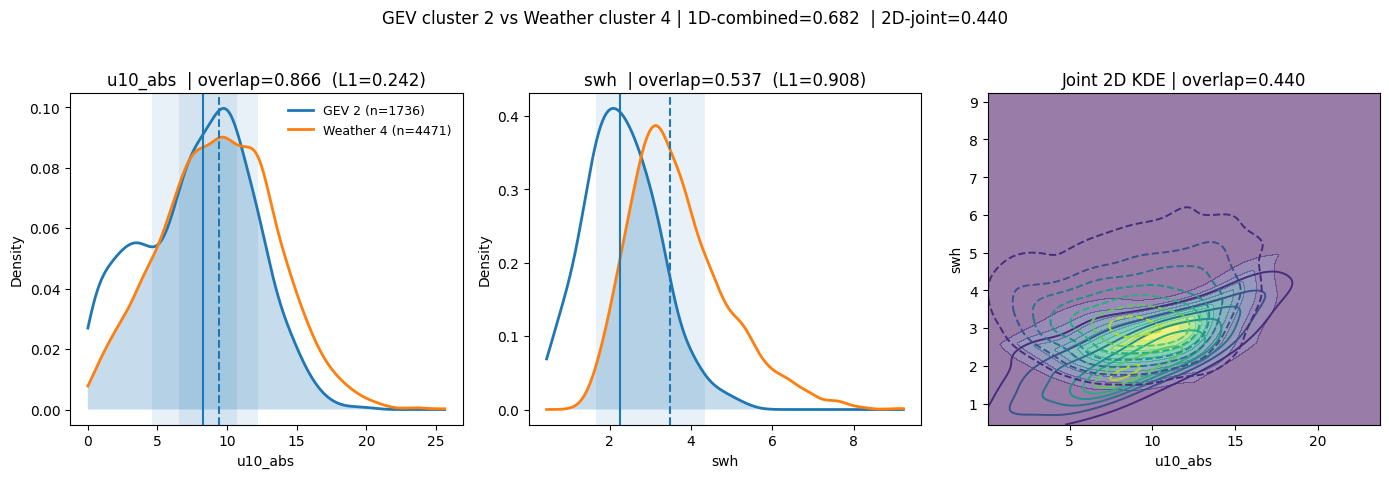

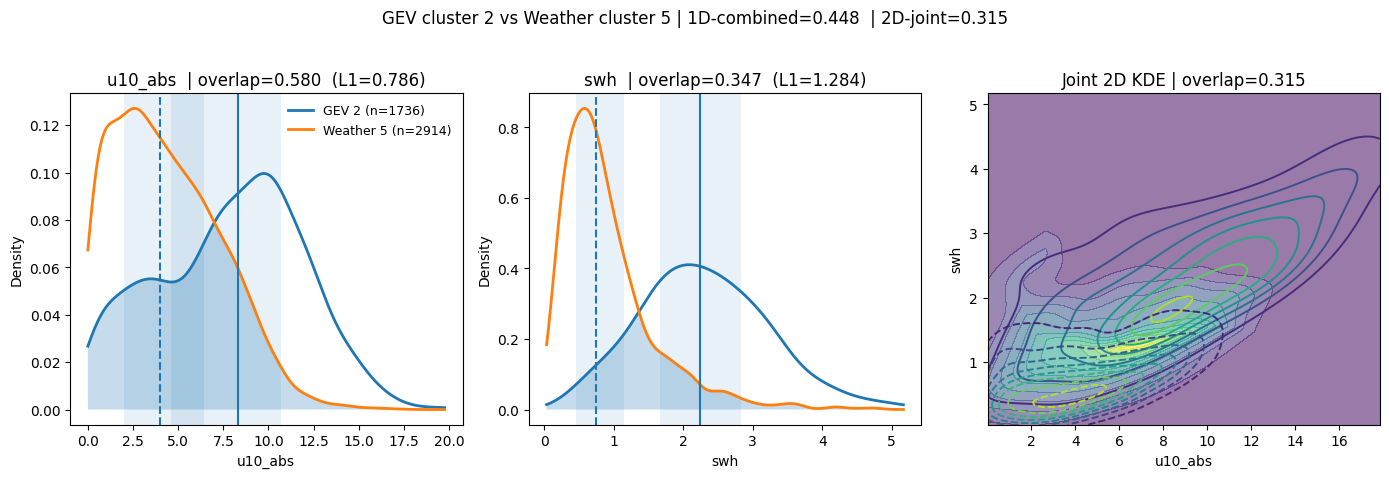

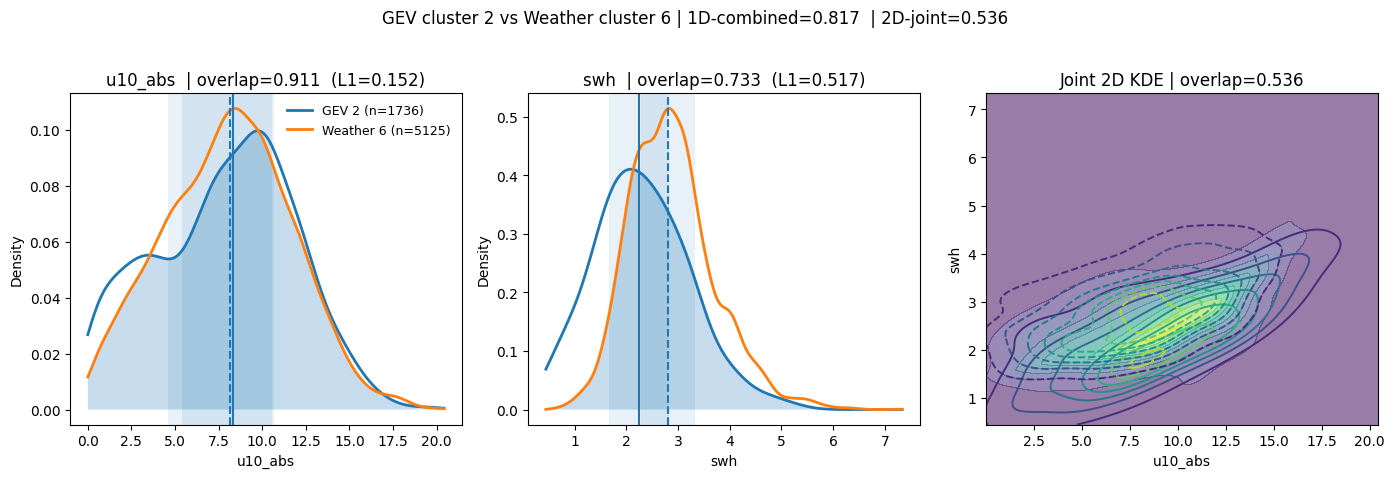

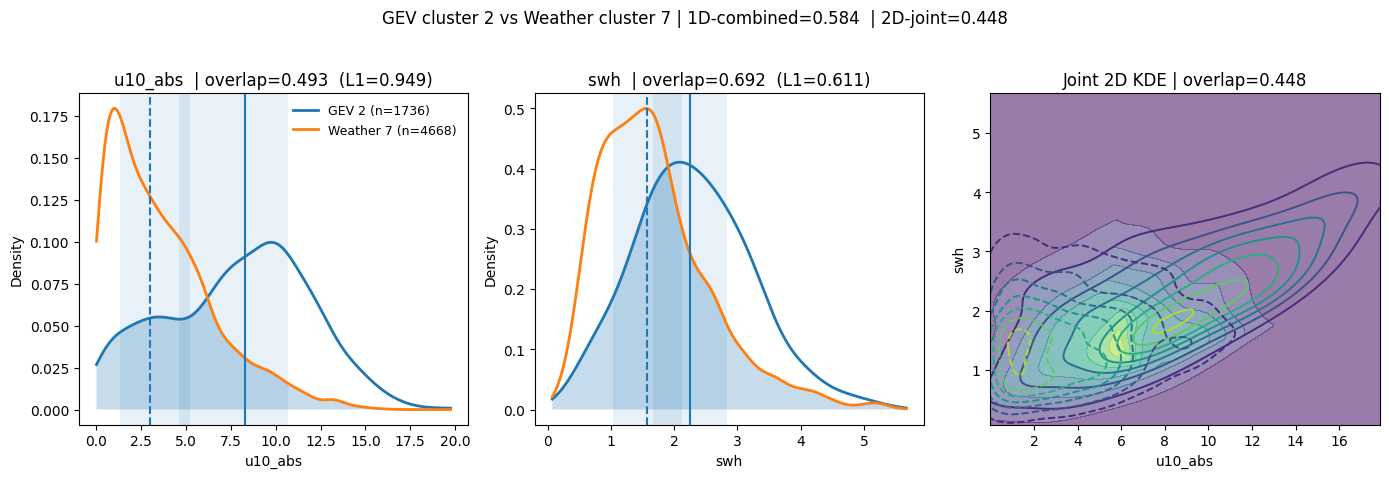

   gev_cluster  weather_cluster  n_gev  n_weather  overlap_u10  overlap_swh  \
0            2                1    166       7575     0.870028     0.698621   
1            2                3    166       6489     0.642138     0.654169   
2            2                6    166       4449     0.910841     0.732569   
3            2                0    166       4765     0.468882     0.583797   
4            2                7    166       3600     0.493245     0.691537   
5            2                4    166       3674     0.866500     0.537142   
6            2                2    166       7104     0.579373     0.415077   
7            2                5    166       2904     0.579914     0.346844   

   overlap_1d_combined  overlap_2d_joint    l1_u10    l1_swh  
0             0.779628          0.567694  0.236411  0.594802  
1             0.648125          0.547360  0.675135  0.682945  
2             0.816856          0.535806  0.151832  0.516996  
3             0.523194          0.52

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

GEV_CLUSTER = 2
WEATHER_CLUSTERS = range(8)

VAR1 = "u10_abs"
VAR2 = "swh"

# -----------------------------
# Helpers
# -----------------------------
def extract_1d(df, cluster_id, col):
    a = (
        df.loc[df["cluster"] == cluster_id, col]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .to_numpy(dtype=float)
    )
    return a

def extract_2d(df, cluster_id, cols):
    A = (
        df.loc[df["cluster"] == cluster_id, list(cols)]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .to_numpy(dtype=float)
    )
    return A

def kde_overlap_1d(a, b, ngrid=2000):
    kde_a = gaussian_kde(a)
    kde_b = gaussian_kde(b)

    xmin = min(a.min(), b.min())
    xmax = max(a.max(), b.max())
    x = np.linspace(xmin, xmax, ngrid)

    fa = kde_a(x)
    fb = kde_b(x)

    overlap = np.trapz(np.minimum(fa, fb), x)     # in [0,1]
    l1 = np.trapz(np.abs(fa - fb), x)             # in [0,2]

    return overlap, l1, x, fa, fb

def kde_overlap_2d(A, B, nx=220, ny=220):
    kdeA = gaussian_kde(A.T)
    kdeB = gaussian_kde(B.T)

    xmin = min(A[:, 0].min(), B[:, 0].min())
    xmax = max(A[:, 0].max(), B[:, 0].max())
    ymin = min(A[:, 1].min(), B[:, 1].min())
    ymax = max(A[:, 1].max(), B[:, 1].max())

    xx, yy = np.mgrid[
        xmin:xmax:complex(nx),
        ymin:ymax:complex(ny),
    ]
    grid = np.vstack([xx.ravel(), yy.ravel()])

    pA = kdeA(grid).reshape(xx.shape)
    pB = kdeB(grid).reshape(xx.shape)

    dx = (xmax - xmin) / (nx - 1)
    dy = (ymax - ymin) / (ny - 1)

    overlap2d = np.sum(np.minimum(pA, pB)) * dx * dy  # in [0,1] (numerical approx)

    return overlap2d, xx, yy, pA, pB

def qstats(a):
    q25, q50, q75 = np.percentile(a, [25, 50, 75])
    return q25, q50, q75

# -----------------------------
# Pull GEV cluster arrays once
# -----------------------------
gev_u = extract_1d(model_df, GEV_CLUSTER, VAR1)
gev_s = extract_1d(model_df, GEV_CLUSTER, VAR2)
gev_2d = extract_2d(model_df, GEV_CLUSTER, (VAR1, VAR2))

if len(gev_u) < 5 or len(gev_s) < 5 or len(gev_2d) < 20:
    raise ValueError("GEV cluster 2 has too few samples for stable KDE(s).")

gev_u_q25, gev_u_q50, gev_u_q75 = qstats(gev_u)
gev_s_q25, gev_s_q50, gev_s_q75 = qstats(gev_s)

rows = []

# -----------------------------
# Loop weather clusters
# -----------------------------
for wc in WEATHER_CLUSTERS:
    w_u = extract_1d(weathercluster_df, wc, VAR1)
    w_s = extract_1d(weathercluster_df, wc, VAR2)
    w_2d = extract_2d(weathercluster_df, wc, (VAR1, VAR2))

    if len(w_u) < 5 or len(w_s) < 5 or len(w_2d) < 20:
        print(f"Skipping weather cluster {wc}: too few samples "
              f"({VAR1} n={len(w_u)}, {VAR2} n={len(w_s)}, 2D n={len(w_2d)})")
        continue

    # --- 1D overlaps ---
    ov_u, l1_u, x_u, f_u_gev, f_u_w = kde_overlap_1d(gev_u, w_u)
    ov_s, l1_s, x_s, f_s_gev, f_s_w = kde_overlap_1d(gev_s, w_s)

    # Combined 1D overlap (geometric mean; strict but interpretable)
    ov_1d_comb = float(np.sqrt(ov_u * ov_s))

    # --- 2D overlap ---
    ov_2d, xx, yy, pA, pB = kde_overlap_2d(gev_2d, w_2d)

    # Stats for annotation
    w_u_q25, w_u_q50, w_u_q75 = qstats(w_u)
    w_s_q25, w_s_q50, w_s_q75 = qstats(w_s)

    rows.append({
        "gev_cluster": GEV_CLUSTER,
        "weather_cluster": wc,
        "n_gev": len(gev_2d),
        "n_weather": len(w_2d),
        "overlap_u10": ov_u,
        "overlap_swh": ov_s,
        "overlap_1d_combined": ov_1d_comb,
        "overlap_2d_joint": ov_2d,
        "l1_u10": l1_u,
        "l1_swh": l1_s,
    })

    # -----------------------------
    # Annotated plots: 1D + 1D + 2D
    # -----------------------------
    fig = plt.figure(figsize=(14, 4.6))

    # Panel 1: u10_abs KDEs + overlap
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(x_u, f_u_gev, linewidth=2, label=f"GEV {GEV_CLUSTER} (n={len(gev_u)})")
    ax1.plot(x_u, f_u_w, linewidth=2, label=f"Weather {wc} (n={len(w_u)})")
    ax1.fill_between(x_u, 0, np.minimum(f_u_gev, f_u_w), alpha=0.25)

    # Medians + IQR shading
    ax1.axvline(gev_u_q50, linewidth=1.5)
    ax1.axvspan(gev_u_q25, gev_u_q75, alpha=0.10)
    ax1.axvline(w_u_q50, linewidth=1.5, linestyle="--")
    ax1.axvspan(w_u_q25, w_u_q75, alpha=0.10)

    ax1.set_xlabel(VAR1)
    ax1.set_ylabel("Density")
    ax1.set_title(f"{VAR1}  | overlap={ov_u:.3f}  (L1={l1_u:.3f})")

    # Panel 2: swh KDEs + overlap
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.plot(x_s, f_s_gev, linewidth=2, label=f"GEV {GEV_CLUSTER} (n={len(gev_s)})")
    ax2.plot(x_s, f_s_w, linewidth=2, label=f"Weather {wc} (n={len(w_s)})")
    ax2.fill_between(x_s, 0, np.minimum(f_s_gev, f_s_w), alpha=0.25)

    ax2.axvline(gev_s_q50, linewidth=1.5)
    ax2.axvspan(gev_s_q25, gev_s_q75, alpha=0.10)
    ax2.axvline(w_s_q50, linewidth=1.5, linestyle="--")
    ax2.axvspan(w_s_q25, w_s_q75, alpha=0.10)

    ax2.set_xlabel(VAR2)
    ax2.set_ylabel("Density")
    ax2.set_title(f"{VAR2}  | overlap={ov_s:.3f}  (L1={l1_s:.3f})")

    # Panel 3: 2D contours + overlap shading
    ax3 = fig.add_subplot(1, 3, 3)
    # show overlap region (min of densities)
    cf = ax3.contourf(xx, yy, np.minimum(pA, pB), levels=12, alpha=0.55)
    ax3.contour(xx, yy, pA, levels=8, linewidths=1.4)                 # GEV solid
    ax3.contour(xx, yy, pB, levels=8, linewidths=1.4, linestyles="--") # Weather dashed

    ax3.set_xlabel(VAR1)
    ax3.set_ylabel(VAR2)
    ax3.set_title(f"Joint 2D KDE | overlap={ov_2d:.3f}")

    # One legend for 1D panels
    ax1.legend(frameon=False, fontsize=9)

    fig.suptitle(
        f"GEV cluster {GEV_CLUSTER} vs Weather cluster {wc} | "
        f"1D-combined={ov_1d_comb:.3f}  | 2D-joint={ov_2d:.3f}",
        y=1.03
    )

    plt.tight_layout()
    plt.show()

# -----------------------------
# Summary table
# -----------------------------
overlap_df = (
    pd.DataFrame(rows)
    .sort_values(["overlap_2d_joint", "overlap_1d_combined"], ascending=False)
    .reset_index(drop=True)
)

# nice display subset
cols_show = [
    "gev_cluster", "weather_cluster",
    "n_gev", "n_weather",
    "overlap_u10", "overlap_swh", "overlap_1d_combined",
    "overlap_2d_joint",
    "l1_u10", "l1_swh",
]
print(overlap_df[cols_show])


In [60]:
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# -----------------------------
# CONFIG
# -----------------------------
GEV_CLUSTERS = range(7)        # sea-level clusters 0–6
WEATHER_CLUSTERS = range(8)    # weather clusters 0–7
VAR1 = "u10_abs"
VAR2 = "swh"

MIN_1D = 5     # minimum samples for 1D KDE
MIN_2D = 20    # minimum samples for 2D KDE

# -----------------------------
# Helpers
# -----------------------------
def extract_1d(df, cluster_id, col):
    return (
        df.loc[df["cluster"] == cluster_id, col]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .to_numpy(dtype=float)
    )

def extract_2d(df, cluster_id, cols):
    return (
        df.loc[df["cluster"] == cluster_id, list(cols)]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .to_numpy(dtype=float)
    )

def kde_overlap_1d(a, b, ngrid=2000):
    kde_a = gaussian_kde(a)
    kde_b = gaussian_kde(b)

    x = np.linspace(min(a.min(), b.min()), max(a.max(), b.max()), ngrid)
    fa = kde_a(x)
    fb = kde_b(x)

    overlap = np.trapz(np.minimum(fa, fb), x)   # [0,1]
    l1 = np.trapz(np.abs(fa - fb), x)           # [0,2]
    return overlap, l1

def kde_overlap_2d(A, B, nx=200, ny=200):
    kdeA = gaussian_kde(A.T)
    kdeB = gaussian_kde(B.T)

    xmin = min(A[:, 0].min(), B[:, 0].min())
    xmax = max(A[:, 0].max(), B[:, 0].max())
    ymin = min(A[:, 1].min(), B[:, 1].min())
    ymax = max(A[:, 1].max(), B[:, 1].max())

    xx, yy = np.mgrid[xmin:xmax:complex(nx), ymin:ymax:complex(ny)]
    grid = np.vstack([xx.ravel(), yy.ravel()])

    pA = kdeA(grid).reshape(xx.shape)
    pB = kdeB(grid).reshape(xx.shape)

    dx = (xmax - xmin) / (nx - 1)
    dy = (ymax - ymin) / (ny - 1)

    overlap2d = np.sum(np.minimum(pA, pB)) * dx * dy
    return overlap2d

# -----------------------------
# Main loop
# -----------------------------
rows = []

for g in GEV_CLUSTERS:
    gev_u = extract_1d(model_df, g, VAR1)
    gev_s = extract_1d(model_df, g, VAR2)
    gev_2d = extract_2d(model_df, g, (VAR1, VAR2))

    if len(gev_u) < MIN_1D or len(gev_s) < MIN_1D or len(gev_2d) < MIN_2D:
        print(f"Skipping GEV cluster {g}: insufficient data")
        continue

    for w in WEATHER_CLUSTERS:
        w_u = extract_1d(weathercluster_df, w, VAR1)
        w_s = extract_1d(weathercluster_df, w, VAR2)
        w_2d = extract_2d(weathercluster_df, w, (VAR1, VAR2))

        if len(w_u) < MIN_1D or len(w_s) < MIN_1D or len(w_2d) < MIN_2D:
            continue

        ov_u, l1_u = kde_overlap_1d(gev_u, w_u)
        ov_s, l1_s = kde_overlap_1d(gev_s, w_s)

        ov_1d = float(np.sqrt(ov_u * ov_s))
        ov_2d = float(kde_overlap_2d(gev_2d, w_2d))

        rows.append({
            "gev_cluster": g,
            "weather_cluster": w,
            "n_gev": len(gev_2d),
            "n_weather": len(w_2d),
            "overlap_u10": ov_u,
            "overlap_swh": ov_s,
            "overlap_1d_combined": ov_1d,
            "overlap_2d_joint": ov_2d,
            "l1_u10": l1_u,
            "l1_swh": l1_s,
        })

# Full results table
overlap_all = pd.DataFrame(rows)


In [61]:
top3_weather_per_gev = (
    overlap_all
    .sort_values(
        ["gev_cluster", "overlap_2d_joint", "overlap_1d_combined"],
        ascending=[True, False, False],
    )
    .groupby("gev_cluster")
    .head(3)
    .reset_index(drop=True)
)

top3_weather_per_gev[
    [
        "gev_cluster",
        "weather_cluster",
        "overlap_u10",
        "overlap_swh",
        "overlap_1d_combined",
        "overlap_2d_joint",
        "n_gev",
        "n_weather",
    ]
]


,gev_cluster,weather_cluster,overlap_u10,overlap_swh,overlap_1d_combined,overlap_2d_joint,n_gev,n_weather
0,0,6,0.839972,0.701615,0.767683,0.669944,25,4449
1,0,3,0.739167,0.673288,0.705459,0.576311,25,6489
2,0,7,0.569512,0.723073,0.641715,0.534553,25,3600
3,1,1,0.761261,0.750494,0.755858,0.603257,14210,7575
4,1,3,0.743553,0.753624,0.748571,0.602915,14210,6489
5,1,7,0.596022,0.851545,0.712418,0.557798,14210,3600
6,2,1,0.870028,0.698621,0.779628,0.567732,166,7575
7,2,3,0.642138,0.654169,0.648125,0.547433,166,6489
8,2,6,0.910841,0.732569,0.816856,0.535829,166,4449
9,3,7,0.696395,0.826019,0.758443,0.663674,14583,3600


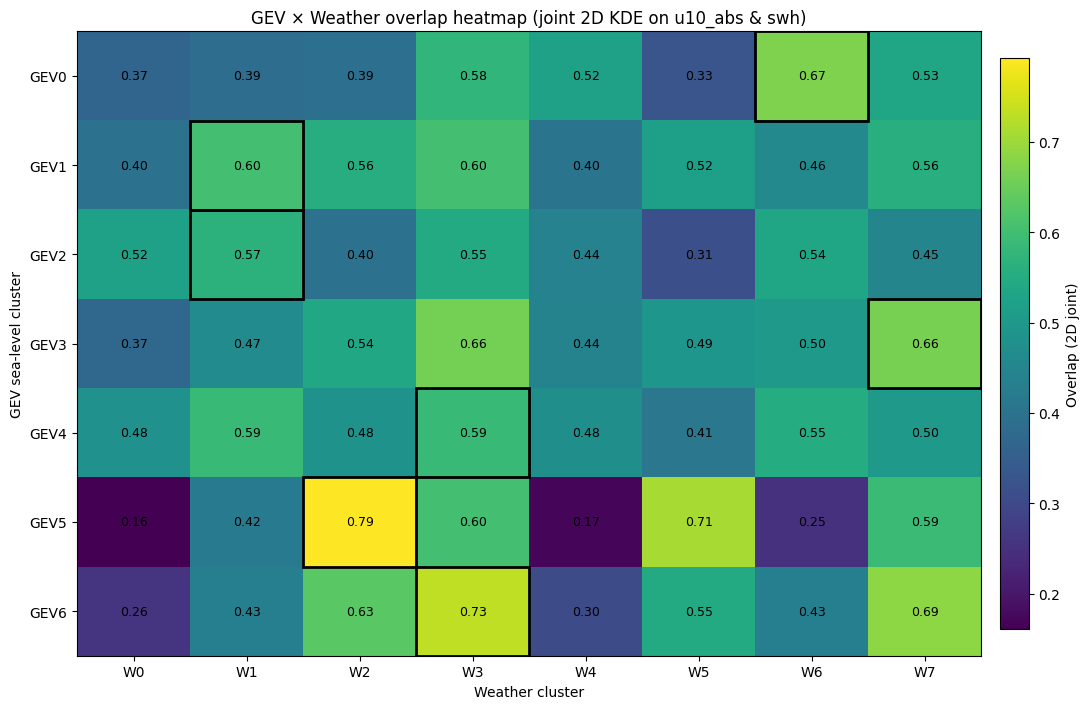

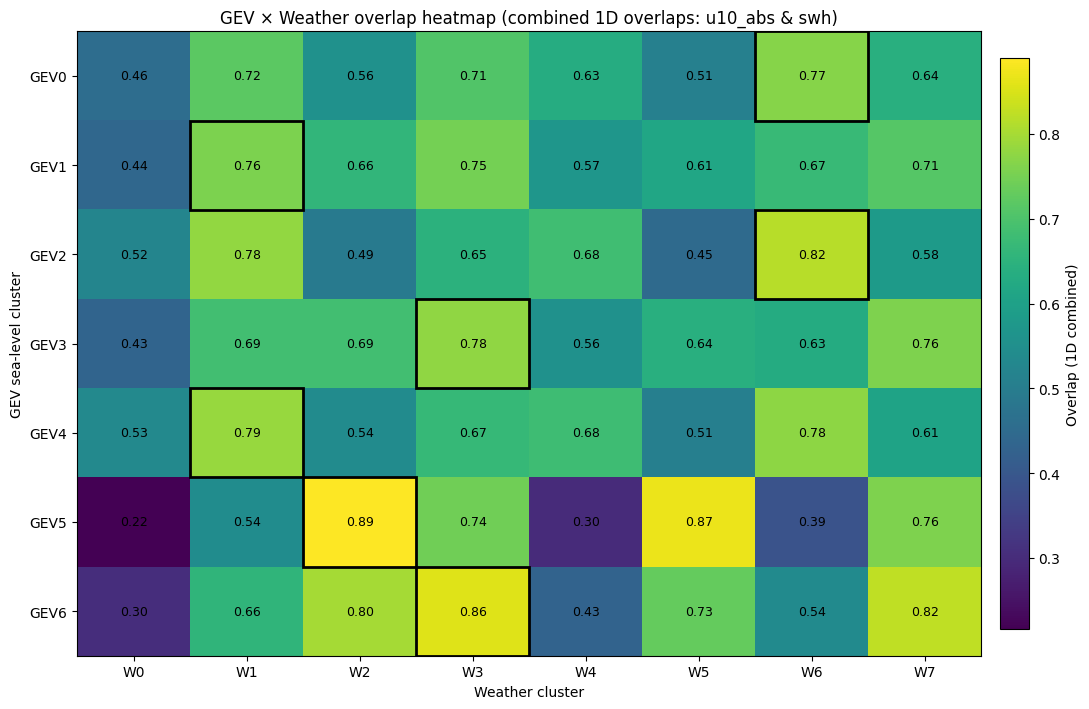

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- assumes you already built overlap_all with columns:
# gev_cluster, weather_cluster, overlap_2d_joint, overlap_1d_combined

# Ensure clusters are ordered nicely
gev_order = sorted(overlap_all["gev_cluster"].unique())
weather_order = sorted(overlap_all["weather_cluster"].unique())

# Pivot to matrices
M2 = (
    overlap_all
    .pivot_table(index="gev_cluster", columns="weather_cluster", values="overlap_2d_joint")
    .reindex(index=gev_order, columns=weather_order)
)

M1 = (
    overlap_all
    .pivot_table(index="gev_cluster", columns="weather_cluster", values="overlap_1d_combined")
    .reindex(index=gev_order, columns=weather_order)
)

def plot_heatmap(M, title, cbar_label, annotate=True):
    fig, ax = plt.subplots(figsize=(1.1 * (M.shape[1] + 2), 0.8 * (M.shape[0] + 2)))

    im = ax.imshow(M.values, aspect="auto")

    # ticks/labels
    ax.set_xticks(np.arange(M.shape[1]))
    ax.set_xticklabels([f"W{c}" for c in M.columns], rotation=0)
    ax.set_yticks(np.arange(M.shape[0]))
    ax.set_yticklabels([f"GEV{r}" for r in M.index])

    ax.set_xlabel("Weather cluster")
    ax.set_ylabel("GEV sea-level cluster")
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(cbar_label)

    # annotate values + highlight row maxima
    if annotate:
        row_max_j = np.nanargmax(M.values, axis=1)  # best weather for each GEV row
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                v = M.values[i, j]
                if np.isnan(v):
                    txt = "NA"
                else:
                    txt = f"{v:.2f}"
                ax.text(j, i, txt, ha="center", va="center", fontsize=9)

            # draw a box around best cell in the row (if row isn't all-NaN)
            if np.isfinite(M.values[i]).any():
                jbest = row_max_j[i]
                ax.add_patch(
                    plt.Rectangle(
                        (jbest - 0.5, i - 0.5),
                        1, 1,
                        fill=False,
                        linewidth=2
                    )
                )

    plt.tight_layout()
    plt.show()

# 1) Joint 2D overlap heatmap (recommended primary)
plot_heatmap(
    M2,
    title="GEV × Weather overlap heatmap (joint 2D KDE on u10_abs & swh)",
    cbar_label="Overlap (2D joint)",
    annotate=True
)

# 2) Optional: combined 1D overlap heatmap
plot_heatmap(
    M1,
    title="GEV × Weather overlap heatmap (combined 1D overlaps: u10_abs & swh)",
    cbar_label="Overlap (1D combined)",
    annotate=True
)
